# Modeling

CRISP-DM Phase 4 for **Predicting Fork-to-PR Conversion in Open-Source Repositories**.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
%matplotlib inline

## 1) Select Modeling Technique

Two target formulations are used to match project success criteria from Stage 1:

- **Classification target**: `has_conversion` (binary, whether repository-season had at least one converted fork).
- **Regression target**: `fork_conversion_rate` (continuous conversion intensity).

Model candidates:
- Baseline predictors
- Logistic Regression (classification)
- Random Forest (classification and regression)
- Gradient Boosting (classification)

These models cover both interpretable linear baseline behavior and non-linear tree-based behavior that can better fit skewed activity data.

## 2) Generate Test Design

- Hold-out strategy: random train/test split (80/20, `random_state=42`).
- Primary metrics:
  - Classification: Accuracy, Macro-F1, Precision, ROC-AUC.
  - Regression: MAE, R2.
- Baselines:
  - Classification: predict majority class.
  - Regression: predict train mean conversion rate.

This gives direct comparability against naive baselines required by the report's success criteria.

In [2]:
DATA_DIRS = [Path("data"), Path("src/data"), Path("../src/data")]
DATA_BASENAME = "modeling_dataset"


def _looks_like_git_lfs_pointer(path: Path) -> bool:
    """Detect tiny text pointer files committed by Git LFS instead of real binary data."""
    try:
        head = path.read_bytes()[:64]
    except Exception:
        return False
    return head.startswith(b"version https://git-lfs.github.com/spec/v1")


candidates = []
for d in DATA_DIRS:
    candidates.append(d / f"{DATA_BASENAME}.parquet")
    candidates.append(d / f"{DATA_BASENAME}.csv")

load_errors = []
df = None
source_used = None

for p in candidates:
    if not p.exists():
        continue
    try:
        if p.suffix == ".parquet":
            if _looks_like_git_lfs_pointer(p):
                raise RuntimeError("Git LFS pointer file detected, not real parquet data")
            df = pd.read_parquet(p)
        else:
            df = pd.read_csv(p)
        source_used = p
        break
    except Exception as e:
        load_errors.append(f"{p}: {e}")

if df is None:
    err_text = "\n".join(load_errors) if load_errors else "No candidate files found"
    raise RuntimeError(
        "Could not load modeling dataset.\n"
        "Reason(s):\n"
        f"{err_text}\n\n"
        "If files are Git LFS pointers, fetch real data with:\n"
        "  git lfs pull\n"
        "or re-export `modeling_dataset.csv` from DataPreparation.ipynb."
    )

print(f"Loaded: {source_used}")
print("Shape:", df.shape)
df.head(3)

Loaded: data/modeling_dataset.parquet
Shape: (100000, 28)


,repo_name,repo_id,season,log1p_issue_comments,log1p_issue_comments_winsor,log1p_issues,log1p_issues_winsor,log1p_pushes,log1p_pushes_winsor,log1p_releases,log1p_releases_winsor,log1p_watches,log1p_watches_winsor,n_forks,n_converted_forks,fork_conversion_rate,n_pr_events,has_conversion,watches,pushes,issues,issue_comments,releases,watches_winsor,pushes_winsor,issues_winsor,issue_comments_winsor,releases_winsor
0,AutomationPanda/awesome-web-testing-playwright,3002,winter_spring,0.693147,0.693147,0.693147,0.693147,0.000000,0.000000,0.0,0.0,3.178054,3.178054,8,0,0.0,0,0,23,0,1,1,0,23.0,0.0,1.0,1.0,0.0
1,Neamar/KISS,16186,summer_autumn,4.143135,4.143135,3.828641,3.828641,3.135494,3.135494,0.0,0.0,4.007333,4.007333,10,3,0.3,35,1,54,22,45,62,0,54.0,22.0,45.0,62.0,0.0
2,magnific0/wondershaper,57159,winter_spring,2.302585,2.302585,1.098612,1.098612,0.000000,0.000000,0.0,0.0,3.401197,3.401197,6,0,0.0,0,0,29,0,2,9,0,29.0,0.0,2.0,9.0,0.0


In [3]:
# Targets
y_cls = df["has_conversion"].astype(int)
y_reg = df["fork_conversion_rate"].astype(float)

# Remove direct leakage columns from features
leak_cols = ["has_conversion", "fork_conversion_rate", "n_converted_forks", "repo_name"]
candidate_features = [c for c in df.columns if c not in leak_cols]

X = df[candidate_features].copy()

# Treat object/string/category/boolean as categorical to avoid numeric imputer errors.
cat_cols = [
    c
    for c in X.columns
    if pd.api.types.is_object_dtype(X[c])
    or pd.api.types.is_string_dtype(X[c])
    or pd.api.types.is_categorical_dtype(X[c])
    or pd.api.types.is_bool_dtype(X[c])
]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Feature columns:", len(candidate_features))
print("Categorical:", cat_cols)
print("Numeric count:", len(num_cols))
print("Class balance (has_conversion):")
display(y_cls.value_counts(normalize=True).rename("share"))

Feature columns: 24
Categorical: ['season']
Numeric count: 23
Class balance (has_conversion):


has_conversion
0    0.52086
1    0.47914
Name: share, dtype: float64

## 3) Build Model

In [4]:
X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
        (
            "cat",
            Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_cols,
        ),
    ],
    remainder="drop",
)

# Classification baselines and models
majority_class = int(y_cls_train.mode()[0])
baseline_cls_pred = np.full_like(y_cls_test, fill_value=majority_class)

clf_models = {
    "logistic_regression": Pipeline(
        [
            ("prep", preprocess),
            ("model", LogisticRegression(max_iter=1200, class_weight="balanced", n_jobs=None)),
        ]
    ),
    "random_forest_clf": Pipeline(
        [
            ("prep", preprocess),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=250,
                    max_depth=14,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1,
                    class_weight="balanced_subsample",
                ),
            ),
        ]
    ),
    "gradient_boosting_clf": Pipeline(
        [
            ("prep", preprocess),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]
    ),
}

cls_results = []
for name, model in clf_models.items():
    model.fit(X_train, y_cls_train)
    pred = model.predict(X_test)
    if hasattr(model.named_steps["model"], "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_cls_test, proba)
    else:
        auc = np.nan
    cls_results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_cls_test, pred),
            "macro_f1": f1_score(y_cls_test, pred, average="macro"),
            "precision": precision_score(y_cls_test, pred, zero_division=0),
            "roc_auc": auc,
        }
    )

baseline_cls = {
    "model": "baseline_majority",
    "accuracy": accuracy_score(y_cls_test, baseline_cls_pred),
    "macro_f1": f1_score(y_cls_test, baseline_cls_pred, average="macro"),
    "precision": precision_score(y_cls_test, baseline_cls_pred, zero_division=0),
    "roc_auc": np.nan,
}

cls_table = pd.DataFrame([baseline_cls] + cls_results).sort_values("macro_f1", ascending=False)
display(cls_table)

# Regression baselines and models
baseline_mean = float(y_reg_train.mean())
baseline_reg_pred = np.full_like(y_reg_test, baseline_mean, dtype=float)

reg_models = {
    "linear_regression": Pipeline([("prep", preprocess), ("model", LinearRegression())]),
    "random_forest_reg": Pipeline(
        [
            ("prep", preprocess),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    max_depth=16,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train, y_reg_train)
    pred = model.predict(X_test)
    reg_results.append(
        {
            "model": name,
            "mae": mean_absolute_error(y_reg_test, pred),
            "r2": r2_score(y_reg_test, pred),
        }
    )

baseline_reg = {
    "model": "baseline_mean",
    "mae": mean_absolute_error(y_reg_test, baseline_reg_pred),
    "r2": r2_score(y_reg_test, baseline_reg_pred),
}

reg_table = pd.DataFrame([baseline_reg] + reg_results).sort_values("mae")
display(reg_table)

,model,accuracy,macro_f1,precision,roc_auc
3,gradient_boosting_clf,0.85140,0.851365,0.808205,0.932880
2,random_forest_clf,0.84805,0.847971,0.800957,0.932143
1,logistic_regression,0.77920,0.777745,0.793613,0.853098
0,baseline_majority,0.52085,0.342473,0.000000,NaN


,model,mae,r2
2,random_forest_reg,0.074961,0.631287
1,linear_regression,0.124935,0.352412
0,baseline_mean,0.158946,-0.000155


## 4) Assess Model

The assessment compares each model against the stage success criteria:

- **Classification**: macro-F1 should exceed naive baseline; precision should be meaningful under class imbalance.
- **Regression**: MAE should be lower than mean baseline and R2 should be positive on test data.

In addition, we inspect predicted probabilities for qualitative calibration behavior and report the top candidate model for each target formulation.

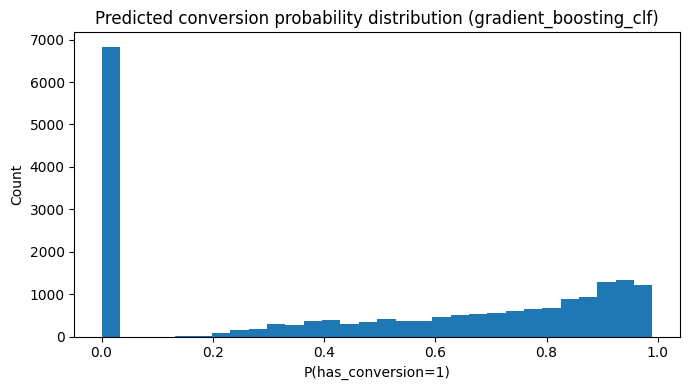

Best classification model: gradient_boosting_clf
Best regression model: random_forest_reg

Quick interpretation:
- If best classification macro-F1 > baseline, model captures conversion signal beyond class prior.
- If best regression MAE < baseline and R2 > 0, model improves over naive mean-rate prediction.


In [5]:
# Refit best classification model for quick diagnostics plot
best_cls_name = cls_table.iloc[0]["model"]
if best_cls_name != "baseline_majority":
    best_cls_model = clf_models[best_cls_name]
    best_cls_model.fit(X_train, y_cls_train)
    if hasattr(best_cls_model.named_steps["model"], "predict_proba"):
        p = best_cls_model.predict_proba(X_test)[:, 1]
        plt.figure(figsize=(7, 4))
        plt.hist(p, bins=30)
        plt.title(f"Predicted conversion probability distribution ({best_cls_name})")
        plt.xlabel("P(has_conversion=1)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

print("Best classification model:", best_cls_name)
print("Best regression model:", reg_table.iloc[0]["model"])

print("\nQuick interpretation:")
print("- If best classification macro-F1 > baseline, model captures conversion signal beyond class prior.")
print("- If best regression MAE < baseline and R2 > 0, model improves over naive mean-rate prediction.")

## 5) Ranking Quality (Precision@10%, Lift@10%, NDCG@10%)

This block evaluates ranking quality for the best classification model and compares it against random-ranking expectation.

,metric,value
0,precision_at_10pct,0.977500
1,base_rate,0.479150
2,lift_at_10pct,2.040071
3,ndcg_at_10pct,0.979460


,decile,samples,positives,precision,lift_vs_base
0,D1,2000,1955,0.9775,2.040071
1,D2,2000,1867,0.9335,1.948242
2,D3,2000,1696,0.8480,1.769801
3,D4,2000,1497,0.7485,1.562141
4,D5,2000,1268,0.6340,1.323176
5,D6,2000,921,0.4605,0.961077
6,D7,2000,379,0.1895,0.395492
7,D8,2000,0,0.0000,0.000000
8,D9,2000,0,0.0000,0.000000
9,D10,2000,0,0.0000,0.000000


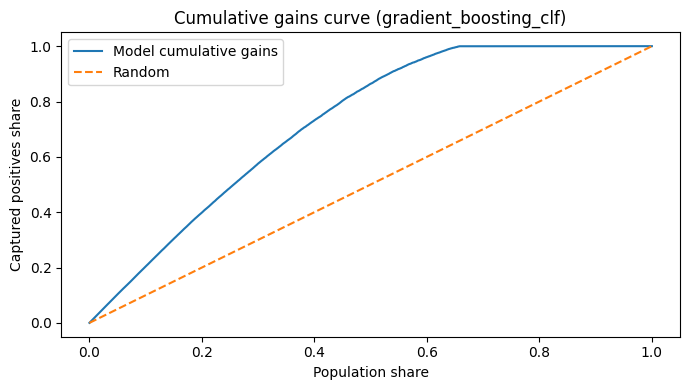

In [6]:
ARTIFACT_DIR = Path("../report/images")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def ndcg_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1]
    y_sorted = np.asarray(y_true)[order][:k]
    gains = (2 ** y_sorted - 1) / np.log2(np.arange(2, k + 2))
    dcg = gains.sum()

    ideal = np.sort(np.asarray(y_true))[::-1][:k]
    ideal_gains = (2 ** ideal - 1) / np.log2(np.arange(2, k + 2))
    idcg = ideal_gains.sum()
    return float(dcg / idcg) if idcg > 0 else np.nan


if best_cls_name != "baseline_majority" and hasattr(best_cls_model.named_steps["model"], "predict_proba"):
    p_test = best_cls_model.predict_proba(X_test)[:, 1]
    y_true = y_cls_test.values

    n = len(y_true)
    k = max(1, int(np.ceil(0.10 * n)))
    order = np.argsort(p_test)[::-1]
    y_top = y_true[order][:k]

    precision_at_10 = y_top.mean()
    base_rate = y_true.mean()
    lift_at_10 = precision_at_10 / base_rate if base_rate > 0 else np.nan
    ndcg_10 = ndcg_at_k(y_true, p_test, k)

    ranking_summary = pd.DataFrame(
        {
            "metric": ["precision_at_10pct", "base_rate", "lift_at_10pct", "ndcg_at_10pct"],
            "value": [precision_at_10, base_rate, lift_at_10, ndcg_10],
        }
    )
    display(ranking_summary)

    # Lift table by decile
    rank_df = pd.DataFrame({"y": y_true, "score": p_test}).sort_values("score", ascending=False).reset_index(drop=True)
    rank_df["decile"] = pd.qcut(rank_df.index + 1, 10, labels=[f"D{i}" for i in range(1, 11)])
    lift_table = (
        rank_df.groupby("decile", observed=False)
        .agg(samples=("y", "size"), positives=("y", "sum"), precision=("y", "mean"))
        .reset_index()
    )
    lift_table["lift_vs_base"] = lift_table["precision"] / base_rate
    display(lift_table)

    # Plot: cumulative lift curve
    cum_pos = np.cumsum(rank_df["y"].values)
    population_share = np.arange(1, n + 1) / n
    captured_share = cum_pos / cum_pos[-1] if cum_pos[-1] > 0 else np.zeros_like(cum_pos)

    plt.figure(figsize=(7, 4))
    plt.plot(population_share, captured_share, label="Model cumulative gains")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("Population share")
    plt.ylabel("Captured positives share")
    plt.title(f"Cumulative gains curve ({best_cls_name})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "modeling_cumulative_gains.png", dpi=150)
    plt.show()
else:
    print("Ranking quality skipped: best classification model has no probability output.")

## 6) Validation Stability (time-based folds)

**Fold definition (this dataset).** Rows are keyed by `season` (`winter_spring` vs `summer_autumn`). A time-based fold is: fit only on rows from one season, evaluate only on rows from the other. We run **both directions** (winter→summer and summer→winter) so there are two temporal folds.

**Success criterion mapping.** The business criterion compares the **best vs worst fold** on the same metric (not random hold-out vs one temporal split). For higher-is-better metrics we report relative drop \((\text{best}-\text{worst})/\text{best}\); for MAE (lower is better) we report \((\text{worst}-\text{best})/\text{best}\).

In [7]:
def _eval_seasonal_fold(train_mask, test_mask):
    """Fit best models on train season, score on test season."""
    X_tr_t, X_te_t = X.loc[train_mask], X.loc[test_mask]
    y_cls_tr_t, y_cls_te_t = y_cls.loc[train_mask], y_cls.loc[test_mask]
    y_reg_tr_t, y_reg_te_t = y_reg.loc[train_mask], y_reg.loc[test_mask]

    out = {}
    if best_cls_name != "baseline_majority":
        m = clf_models[best_cls_name]
        m.fit(X_tr_t, y_cls_tr_t)
        pred = m.predict(X_te_t)
        proba = m.predict_proba(X_te_t)[:, 1] if hasattr(m.named_steps["model"], "predict_proba") else None
        out["macro_f1"] = f1_score(y_cls_te_t, pred, average="macro")
        out["roc_auc"] = roc_auc_score(y_cls_te_t, proba) if proba is not None else np.nan

    best_reg_name = reg_table.iloc[0]["model"]
    if best_reg_name != "baseline_mean":
        mr = reg_models[best_reg_name]
        mr.fit(X_tr_t, y_reg_tr_t)
        pred_r = mr.predict(X_te_t)
        out["mae"] = mean_absolute_error(y_reg_te_t, pred_r)
        out["r2"] = r2_score(y_reg_te_t, pred_r)

    return out


if "season" in X.columns and set(df["season"].astype(str).unique()) >= {"winter_spring", "summer_autumn"}:
    w = df["season"].astype(str) == "winter_spring"
    s = df["season"].astype(str) == "summer_autumn"

    fold_ws_to_sa = _eval_seasonal_fold(w, s)
    fold_sa_to_ws = _eval_seasonal_fold(s, w)

    fold_table = pd.DataFrame(
        [
            {"fold": "train_winter_spring__test_summer_autumn", **fold_ws_to_sa},
            {"fold": "train_summer_autumn__test_winter_spring", **fold_sa_to_ws},
        ]
    )
    display(fold_table)

    # Best vs worst fold gaps (matches business wording)
    def gap_higher_is_better(a, b):
        best, worst = max(a, b), min(a, b)
        return best, worst, (best - worst) / best * 100 if best else np.nan

    def gap_lower_is_better(a, b):
        best, worst = min(a, b), max(a, b)
        return best, worst, (worst - best) / best * 100 if best else np.nan

    mf1_a, mf1_b = fold_ws_to_sa["macro_f1"], fold_sa_to_ws["macro_f1"]
    auc_a, auc_b = fold_ws_to_sa["roc_auc"], fold_sa_to_ws["roc_auc"]
    mae_a, mae_b = fold_ws_to_sa["mae"], fold_sa_to_ws["mae"]
    r2_a, r2_b = fold_ws_to_sa["r2"], fold_sa_to_ws["r2"]

    b1, w1, g1 = gap_higher_is_better(mf1_a, mf1_b)
    b2, w2, g2 = gap_higher_is_better(auc_a, auc_b)
    b3, w3, g3 = gap_lower_is_better(mae_a, mae_b)
    b4, w4, g4 = gap_higher_is_better(r2_a, r2_b)

    stability_gap = pd.DataFrame(
        {
            "metric": ["macro_f1", "roc_auc", "mae", "r2"],
            "best_fold_value": [b1, b2, b3, b4],
            "worst_fold_value": [w1, w2, w3, w4],
            "relative_gap_pct": [g1, g2, g3, g4],
            "passes_15pct_rule": [g <= 15 for g in [g1, g2, g3, g4]],
        }
    )
    display(stability_gap)
else:
    print("Validation stability skipped: seasonal folds are unavailable in this dataset.")

,fold,macro_f1,roc_auc,mae,r2
0,train_winter_spring__test_summer_autumn,0.809358,0.908607,0.082442,0.442514
1,train_summer_autumn__test_winter_spring,0.854884,0.940360,0.084692,0.577385


,metric,best_fold_value,worst_fold_value,relative_gap_pct,passes_15pct_rule
0,macro_f1,0.854884,0.809358,5.325414,True
1,roc_auc,0.940360,0.908607,3.376682,True
2,mae,0.082442,0.084692,2.728985,True
3,r2,0.577385,0.442514,23.359011,False


## 7) Feature Interpretability (Top-5 features)

We use permutation importance on the hold-out set for the best classification model and report top-5 features.

,feature,importance_mean,importance_std
0,num__n_pr_events,0.326116,0.004712
1,num__issue_comments_winsor,0.001664,0.000584
2,num__n_forks,0.001476,0.000594
3,num__issue_comments,0.001141,0.000489
4,cat__season_winter_spring,0.000972,0.000637


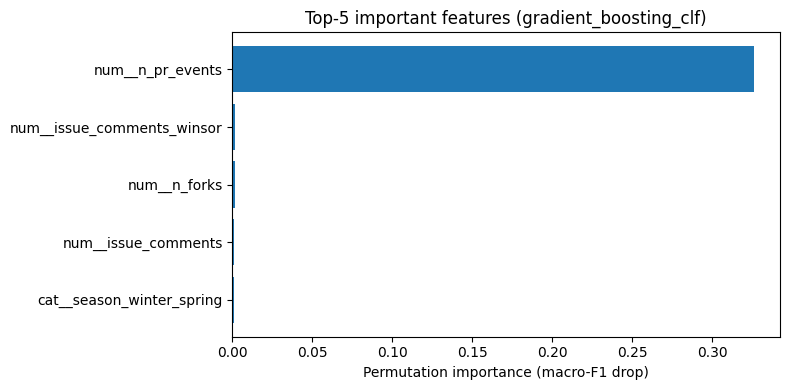

In [8]:
if best_cls_name != "baseline_majority":
    best_cls_model.fit(X_train, y_cls_train)

    prep = best_cls_model.named_steps["prep"]
    model = best_cls_model.named_steps["model"]

    X_test_trans = prep.transform(X_test)
    feat_names = prep.get_feature_names_out()

    p_imp = permutation_importance(
        model,
        X_test_trans,
        y_cls_test.values,
        n_repeats=8,
        random_state=42,
        scoring="f1_macro",
        n_jobs=-1,
    )

    imp_df = pd.DataFrame({
        "feature": feat_names,
        "importance_mean": p_imp.importances_mean,
        "importance_std": p_imp.importances_std,
    }).sort_values("importance_mean", ascending=False)

    top5 = imp_df.head(5).reset_index(drop=True)
    display(top5)

    plt.figure(figsize=(8, 4))
    plt.barh(top5["feature"][::-1], top5["importance_mean"][::-1])
    plt.xlabel("Permutation importance (macro-F1 drop)")
    plt.title(f"Top-5 important features ({best_cls_name})")
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "modeling_top5_features.png", dpi=150)
    plt.show()
else:
    print("Feature interpretability skipped: baseline model selected.")

## 8) Sensitivity Check (90-day observation window)

Fork-to-PR conversion labels in this pipeline use a **single 90-day post-fork observation window** (from Data Preparation: `OBSERVATION_DAYS = 90`).

In [11]:
OBSERVATION_DAYS = 90

sensitivity_note = pd.DataFrame(
    [
        {
            "item": "label_window",
            "value": f"{OBSERVATION_DAYS} days post-fork (Data Preparation)",
        },
        {
            "item": "alternate_windows_in_notebook",
            "value": "not used (single 90-day definition only)",
        },
    ]
)
display(sensitivity_note)

,item,value
0,label_window,90 days post-fork (Data Preparation)
1,alternate_windows_in_notebook,not used (single 90-day definition only)


## 9) Hyperparameter Tuning (compact randomized search)

A compact search is added for one strong classifier and one strong regressor to improve final quality without excessive runtime.

In [ ]:
# Classification tuning: RandomForestClassifier
rf_clf_pipe = Pipeline(
    [
        ("prep", preprocess),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced_subsample")),
    ]
)

rf_clf_params = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_clf_search = RandomizedSearchCV(
    rf_clf_pipe,
    rf_clf_params,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
rf_clf_search.fit(X_train, y_cls_train)

best_rf_clf = rf_clf_search.best_estimator_
pred_rf = best_rf_clf.predict(X_test)
proba_rf = best_rf_clf.predict_proba(X_test)[:, 1]

# Regression tuning: RandomForestRegressor
rf_reg_pipe = Pipeline(
    [
        ("prep", preprocess),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]
)

rf_reg_params = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [10, 14, 18, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.6],
}

rf_reg_search = RandomizedSearchCV(
    rf_reg_pipe,
    rf_reg_params,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
rf_reg_search.fit(X_train, y_reg_train)

best_rf_reg = rf_reg_search.best_estimator_
pred_rf_reg = best_rf_reg.predict(X_test)

tuning_results = pd.DataFrame(
    [
        {
            "track": "classification",
            "model": "rf_tuned",
            "macro_f1": f1_score(y_cls_test, pred_rf, average="macro"),
            "roc_auc": roc_auc_score(y_cls_test, proba_rf),
            "best_params": str(rf_clf_search.best_params_),
        },
        {
            "track": "regression",
            "model": "rf_tuned",
            "mae": mean_absolute_error(y_reg_test, pred_rf_reg),
            "r2": r2_score(y_reg_test, pred_rf_reg),
            "best_params": str(rf_reg_search.best_params_),
        },
    ]
)

display(tuning_results)

try:
    _stability_gap_df = stability_gap
except NameError:
    _stability_gap_df = None

try:
    _sensitivity_note_df = sensitivity_note
except NameError:
    _sensitivity_note_df = None

# Final success-criteria digest
success_digest = {
    "conversion_rate_prediction": {
        "mae_better_than_baseline": float(mean_absolute_error(y_reg_test, pred_rf_reg) < baseline_reg["mae"]),
        "r2_positive": float(r2_score(y_reg_test, pred_rf_reg) > 0),
    },
    "classification": {
        "macro_f1_gain_vs_baseline": float(f1_score(y_cls_test, pred_rf, average="macro") - baseline_cls["macro_f1"]),
    },
    "ranking_quality": {
        "precision_at_10pct": float(precision_at_10) if "precision_at_10" in locals() else np.nan,
        "lift_at_10pct": float(lift_at_10) if "lift_at_10" in locals() else np.nan,
        "ndcg_at_10pct": float(ndcg_10) if "ndcg_10" in locals() else np.nan,
    },
    "validation_stability": {
        "seasonal_folds_evaluated": float(_stability_gap_df is not None),
        "all_metrics_within_15pct_best_vs_worst_fold": (
            float(bool(_stability_gap_df["passes_15pct_rule"].all()))
            if _stability_gap_df is not None
            else float("nan")
        ),
    },
    "feature_interpretability": {
        "top5_available": float("top5" in locals()),
    },
    "sensitivity_check": {
        "label_window_days": 90,
        "documented_in_notebook": float(_sensitivity_note_df is not None),
    },
}

success_digest

,track,model,macro_f1,roc_auc,best_params,mae,r2
0,classification,rf_tuned,0.850316,0.932198,"{'model__n_estimators': 200, 'model__min_sampl...",NaN,NaN
1,regression,rf_tuned,NaN,NaN,"{'model__n_estimators': 200, 'model__min_sampl...",0.075005,0.633798


{'conversion_rate_prediction': {'mae_better_than_baseline': 1.0,
  'r2_positive': 1.0},
 'classification': {'macro_f1_gain_vs_baseline': 0.5078429647508771},
 'ranking_quality': {'precision_at_10pct': 0.9775,
  'lift_at_10pct': 2.040070958989878,
  'ndcg_at_10pct': 0.9794601785999277},
 'validation_stability': {'seasonal_folds_evaluated': 1.0,
  'all_metrics_within_15pct_best_vs_worst_fold': 0.0},
 'feature_interpretability': {'top5_available': 1.0},
 'sensitivity_check': {'label_window_days': 90, 'documented_in_notebook': 1.0}}